In [1]:
import pandas as pd
import numpy as np
import os

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [2]:
DATA_PATH = "../data/raw/"

In [3]:
customers = pd.read_csv(r"D:\PROJECTS\Ecommerce-Dashboard\data\olist_customers_dataset.csv")
geolocation = pd.read_csv(r"D:\PROJECTS\Ecommerce-Dashboard\data\olist_geolocation_dataset.csv")
order_items = pd.read_csv(r"D:\PROJECTS\Ecommerce-Dashboard\data\olist_order_items_dataset.csv")
payments = pd.read_csv(r"D:\PROJECTS\Ecommerce-Dashboard\data\olist_order_payments_dataset.csv")
reviews = pd.read_csv(r"D:\PROJECTS\Ecommerce-Dashboard\data\olist_order_reviews_dataset.csv")
orders = pd.read_csv(r"D:\PROJECTS\Ecommerce-Dashboard\data\olist_orders_dataset.csv")
products = pd.read_csv(r"D:\PROJECTS\Ecommerce-Dashboard\data\olist_products_dataset.csv")
sellers = pd.read_csv(r"D:\PROJECTS\Ecommerce-Dashboard\data\olist_sellers_dataset.csv")
category_translation = pd.read_csv(r"D:\PROJECTS\Ecommerce-Dashboard\data\product_category_name_translation.csv")

In [4]:
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Payments:", payments.shape)
print("Products:", products.shape)
print("Sellers:", sellers.shape)
print("Reviews:", reviews.shape)

Customers: (99441, 5)
Orders: (99441, 8)
Order Items: (112650, 7)
Payments: (103886, 5)
Products: (32951, 9)
Sellers: (3095, 4)
Reviews: (99224, 7)


In [5]:
customers.head()


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [6]:
orders.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [7]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [8]:
# Select useful columns only (reduces complexity)

customers = customers[['customer_id', 'customer_unique_id', 'customer_city', 'customer_state']]

orders = orders[['order_id', 'customer_id', 'order_purchase_timestamp', 'order_status']]

order_items = order_items[['order_id', 'product_id', 'seller_id', 'price', 'freight_value']]

payments = payments[['order_id', 'payment_value']]

products = products[['product_id', 'product_category_name']]


In [9]:
# Merge orders with customers
df = pd.merge(orders, customers, on='customer_id', how='left')

# Merge with order items
df = pd.merge(df, order_items, on='order_id', how='left')

# Merge with payments
df = pd.merge(df, payments, on='order_id', how='left')

# Merge with products
df = pd.merge(df, products, on='product_id', how='left')

# Final dataset shape
print("Final Dataset Shape:", df.shape)

Final Dataset Shape: (118434, 13)


In [10]:
df.isnull().sum()

order_id                       0
customer_id                    0
order_purchase_timestamp       0
order_status                   0
customer_unique_id             0
customer_city                  0
customer_state                 0
product_id                   830
seller_id                    830
price                        830
freight_value                830
payment_value                  3
product_category_name       2528
dtype: int64

In [11]:
df.dtypes

order_id                     object
customer_id                  object
order_purchase_timestamp     object
order_status                 object
customer_unique_id           object
customer_city                object
customer_state               object
product_id                   object
seller_id                    object
price                       float64
freight_value               float64
payment_value               float64
product_category_name        object
dtype: object

In [12]:
# Drop rows with missing product category
df = df.dropna(subset=['product_category_name'])

# Fill missing payment values
df['payment_value'] = df['payment_value'].fillna(0)

In [13]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

In [14]:
# Extract time features
df['order_year'] = df['order_purchase_timestamp'].dt.year
df['order_month'] = df['order_purchase_timestamp'].dt.month
df['order_day'] = df['order_purchase_timestamp'].dt.day

In [15]:
df['total_price'] = df['price'] + df['freight_value']

In [16]:
df.head()

,order_id,customer_id,order_purchase_timestamp,order_status,customer_unique_id,customer_city,customer_state,product_id,seller_id,price,freight_value,payment_value,product_category_name,order_year,order_month,order_day,total_price
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,delivered,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,18.12,utilidades_domesticas,2017,10,2,38.71
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,delivered,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,2.00,utilidades_domesticas,2017,10,2,38.71
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,delivered,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,18.59,utilidades_domesticas,2017,10,2,38.71
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,delivered,af07308b275d755c9edb36a90c618231,barreiras,BA,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,118.70,22.76,141.46,perfumaria,2018,7,24,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,delivered,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,159.90,19.22,179.12,automotivo,2018,8,8,179.12


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 115906 entries, 0 to 118433
Data columns (total 17 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   order_id                  115906 non-null  object        
 1   customer_id               115906 non-null  object        
 2   order_purchase_timestamp  115906 non-null  datetime64[ns]
 3   order_status              115906 non-null  object        
 4   customer_unique_id        115906 non-null  object        
 5   customer_city             115906 non-null  object        
 6   customer_state            115906 non-null  object        
 7   product_id                115906 non-null  object        
 8   seller_id                 115906 non-null  object        
 9   price                     115906 non-null  float64       
 10  freight_value             115906 non-null  float64       
 11  payment_value             115906 non-null  float64       
 12  product

# Data Analysis + Insights

In [18]:
# Total Revenue
df['total_price'].sum()

np.float64(16345112.040000001)

In [19]:
# Revenue by Year
df.groupby('order_year')['total_price'].sum()

order_year
2016      58828.48
2017    7393847.29
2018    8892436.27
Name: total_price, dtype: float64

In [20]:
# Revenue by Month
monthly_revenue = df.groupby('order_month')['total_price'].sum()
monthly_revenue

order_month
1     1268108.44
2     1304872.39
3     1633700.13
4     1626166.92
5     1802823.33
6     1591814.34
7     1711595.27
8     1729177.40
9      756078.23
10     839575.67
11    1204760.32
12     876439.60
Name: total_price, dtype: float64

In [21]:
import matplotlib.pyplot as plt

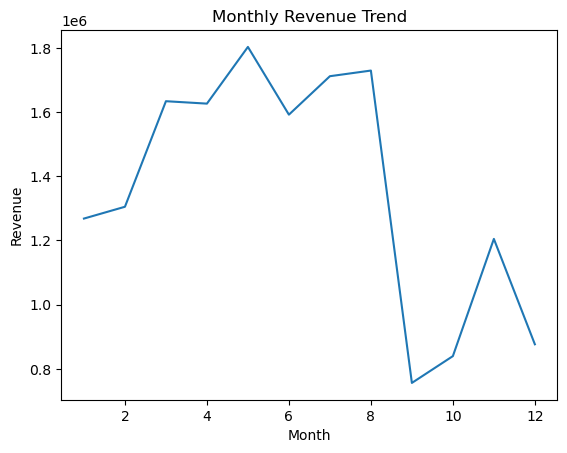

In [22]:
monthly_revenue.plot(kind='line')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

In [23]:
# Top Cities
top_cities = df.groupby('customer_city')['total_price'].sum().sort_values(ascending=False).head(10)
top_cities

customer_city
sao paulo         2241484.35
rio de janeiro    1187092.63
belo horizonte     425278.20
brasilia           360893.07
curitiba           250535.12
salvador           229279.42
porto alegre       227694.25
campinas           219283.15
guarulhos          174232.62
niteroi            153557.18
Name: total_price, dtype: float64

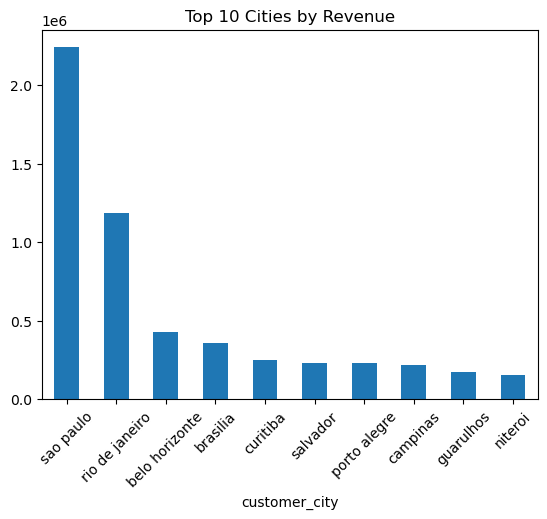

In [24]:
top_cities.plot(kind='bar')
plt.title("Top 10 Cities by Revenue")
plt.xticks(rotation=45)
plt.show()

In [25]:
# Top Products
top_products = df['product_category_name'].value_counts().head(10)
top_products

product_category_name
cama_mesa_banho           11823
beleza_saude               9975
esporte_lazer              8945
moveis_decoracao           8744
informatica_acessorios     8082
utilidades_domesticas      7355
relogios_presentes         6201
telefonia                  4721
ferramentas_jardim         4574
automotivo                 4379
Name: count, dtype: int64

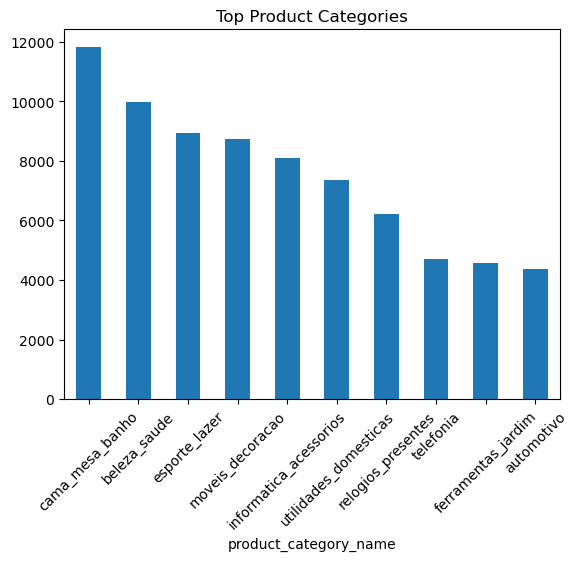

In [26]:
top_products.plot(kind='bar')
plt.title("Top Product Categories")
plt.xticks(rotation=45)
plt.show()

In [27]:
# Order Status Distribution
df['order_status'].value_counts()

order_status
delivered      113410
shipped          1214
canceled          551
processing        362
invoiced          359
unavailable         7
approved            3
Name: count, dtype: int64

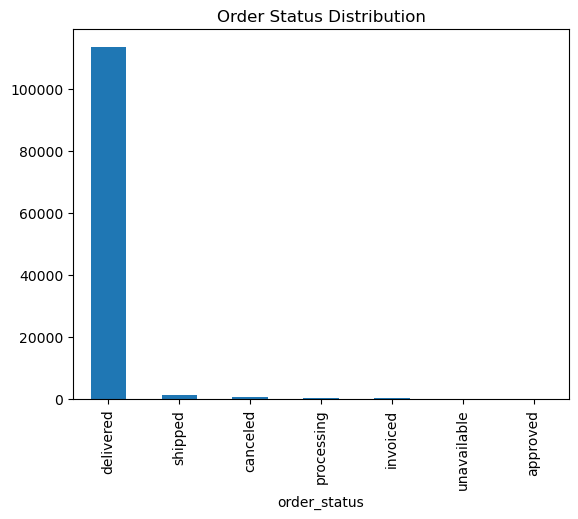

In [28]:

df['order_status'].value_counts().plot(kind='bar')
plt.title("Order Status Distribution")
plt.show()

In [29]:
monthly_revenue = df.groupby('order_month')['total_price'].sum().sort_index()

In [30]:
df.to_csv("../data/cleaned_data.csv", index=False)